## Exploratory Data Analysis (EDA)

Pada tahap ini dilakukan eksplorasi distribusi data untuk memahami karakteristik
masing-masing fitur serta mendeteksi keberadaan outlier menggunakan histogram
dan boxplot.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [20]:
df_california = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [21]:
# untuk plot Q-Q
import scipy.stats as stats

In [22]:
df_california.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [23]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

In [24]:
df_california.columns.tolist()

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

In [25]:
df_california.head()
df_california.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

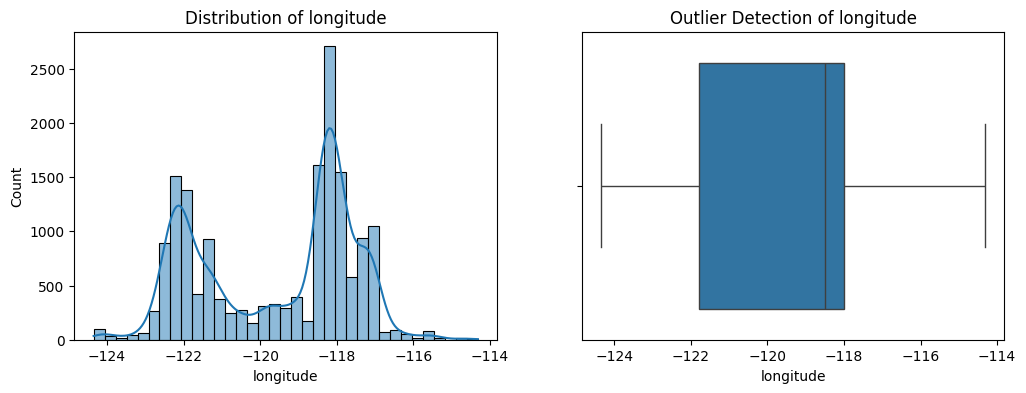

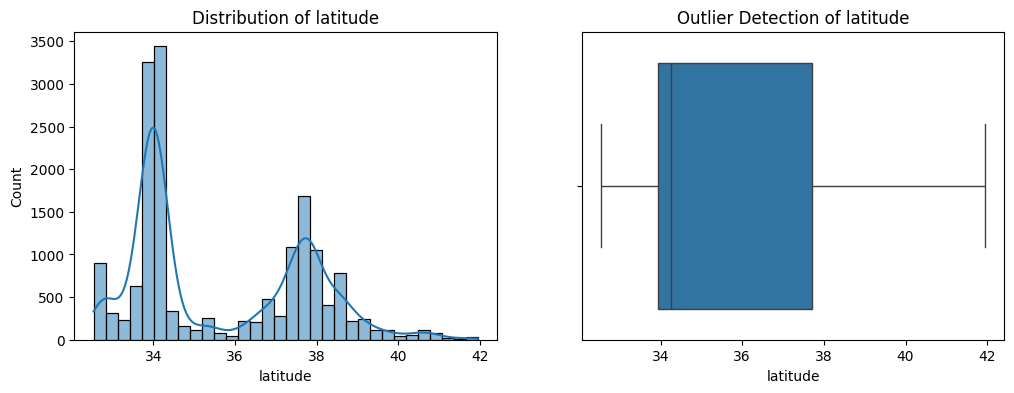

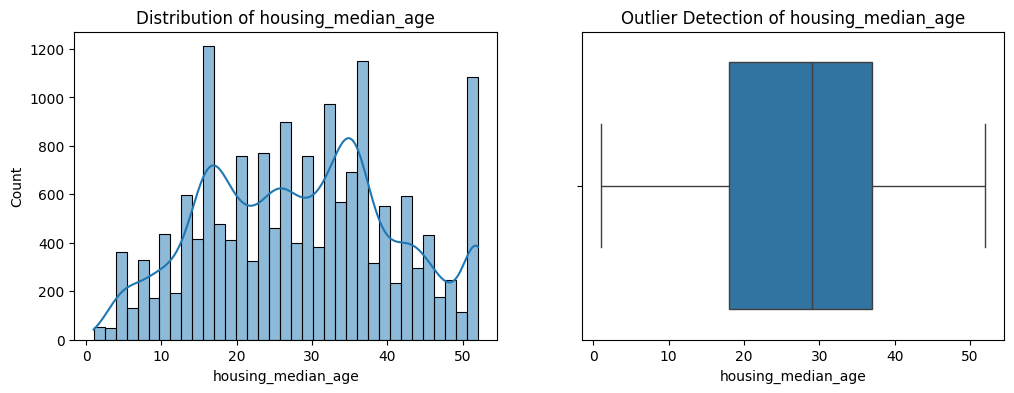

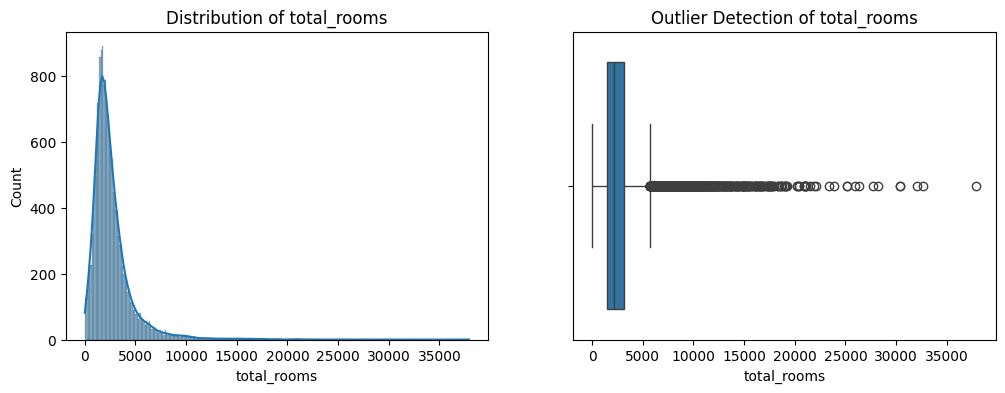

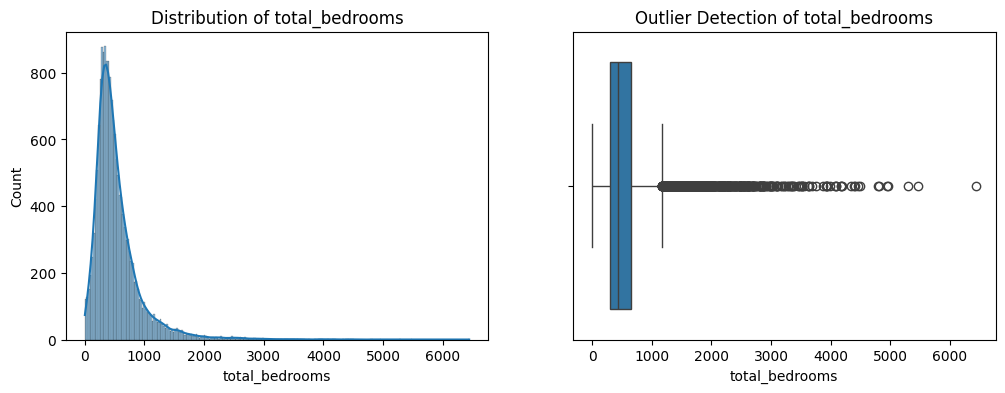

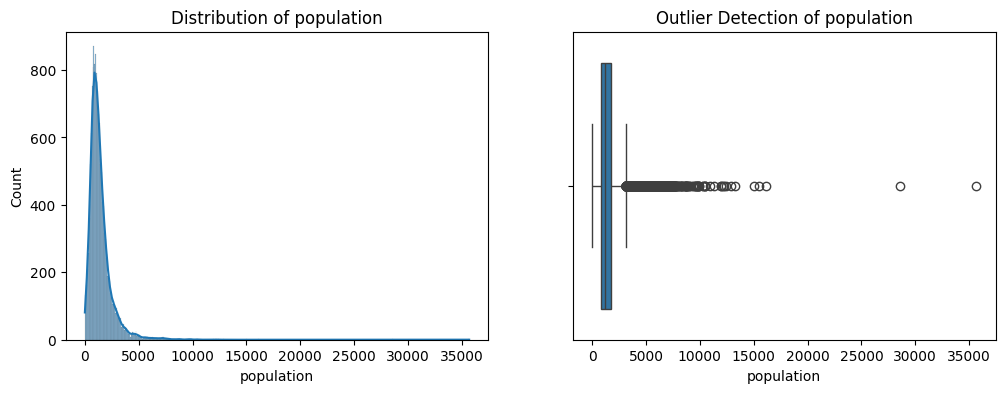

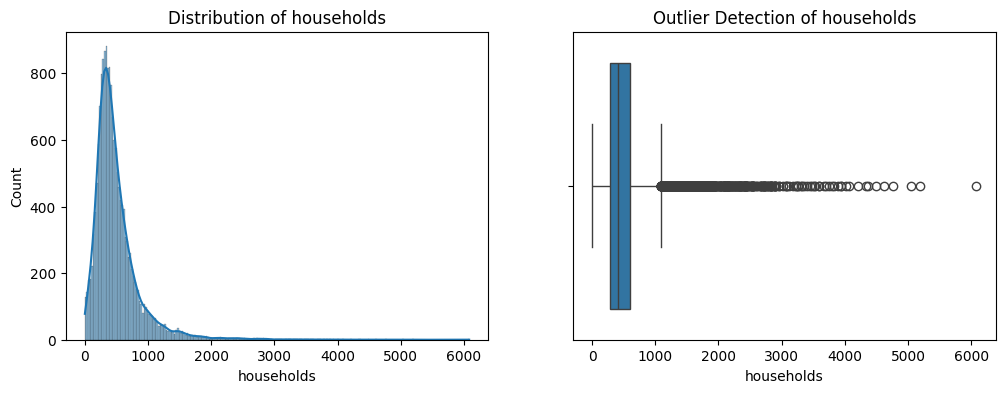

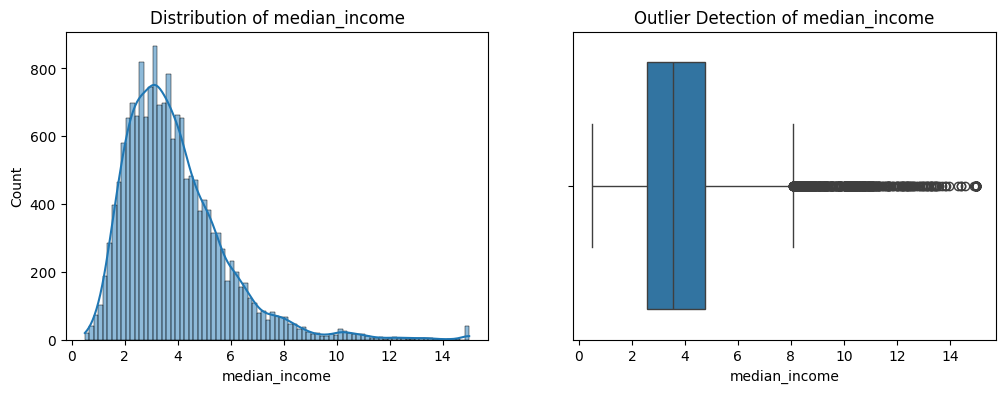

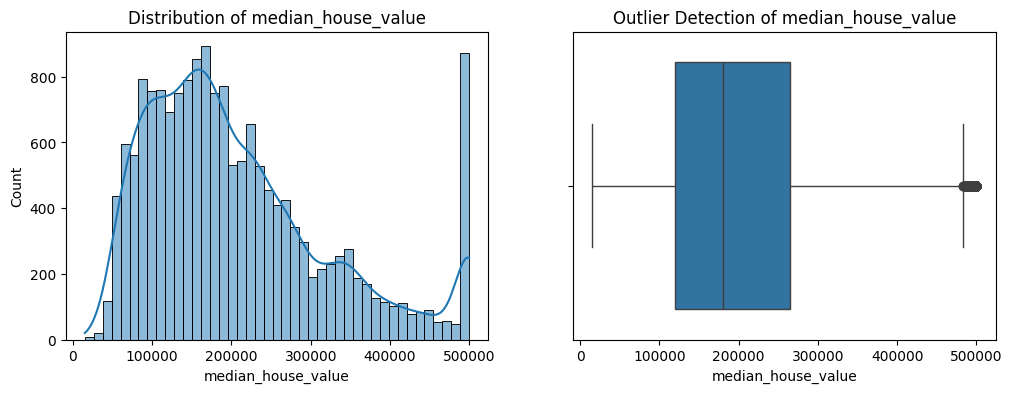

In [26]:
columns = df_california.columns

for col in columns:

    if df_california[col].dtype != 'object':

        plt.figure(figsize=(12,4))

        plt.subplot(1,2,1)
        sns.histplot(df_california[col], kde=True)
        plt.title(f'Distribution of {col}')

        plt.subplot(1,2,2)
        sns.boxplot(x=df_california[col])
        plt.title(f'Outlier Detection of {col}')

        plt.show()

In [27]:
df_california = df_california.rename(columns={'median_income': 'MedInc', 'housing_median_age': 'HouseAge'})

In [28]:
# Create derived columns AveRooms, AveBedrms, and AveOccup
df_california['AveRooms'] = df_california['total_rooms'] / df_california['households']
df_california['AveBedrms'] = df_california['total_bedrooms'] / df_california['households']
df_california['AveOccup'] = df_california['population'] / df_california['households']

# Display the first few rows to confirm the new column names and derived features
display(df_california.head())

,longitude,latitude,HouseAge,total_rooms,total_bedrooms,population,households,MedInc,median_house_value,AveRooms,AveBedrms,AveOccup
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,11.889831,2.718220,2.150424
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,16.522678,4.105832,2.438445
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,6.153846,1.487179,2.846154
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,6.641593,1.491150,2.278761
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,5.549618,1.244275,2.381679


### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [29]:
col = 'total_rooms'

In [30]:
Q1 = df_california[col].quantile(0.25)
Q3 = df_california[col].quantile(0.75)

print("Q1 :", Q1)
print("Q3 :", Q3)

Q1 : 1462.0
Q3 : 3151.25


In [31]:
IQR = Q3 - Q1
print("IQR :", IQR)

IQR : 1689.25


In [32]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound :", lower_bound)
print("Upper Bound :", upper_bound)

Lower Bound : -1071.875
Upper Bound : 5685.125


In [33]:
df_california_clean = df_california[
    (df_california[col] >= lower_bound) &
    (df_california[col] <= upper_bound)
]

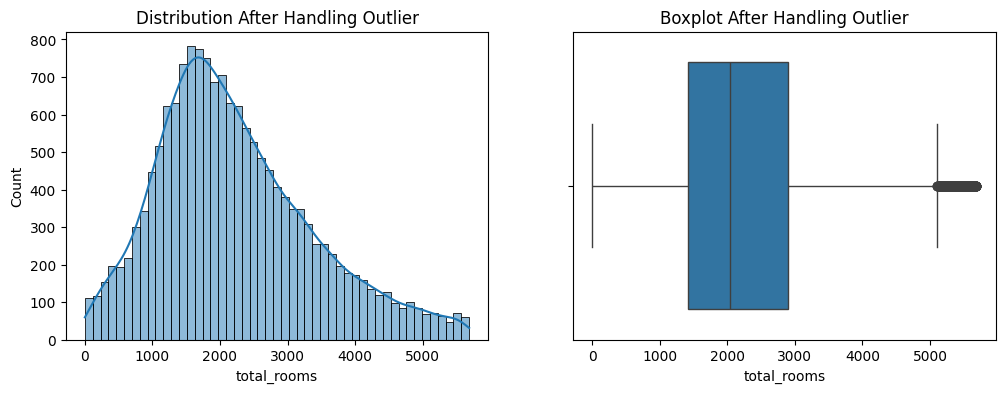

In [34]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(df_california_clean[col], kde=True)
plt.title("Distribution After Handling Outlier")

plt.subplot(1,2,2)
sns.boxplot(x=df_california_clean[col])
plt.title("Boxplot After Handling Outlier")

plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df_company = pd.read_csv('company.csv')

In [37]:
import os
os.listdir()

['.config',
 'TelcoCustomerChurn.csv',
 'company.csv',
 'TelcoCustomerChurn.xlsx',
 'sample_data']

In [38]:
import pandas as pd

df_company = pd.read_csv('company.csv')

In [39]:
df_company.head()

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


In [40]:
# cek jumlah missing value pada kolom Headquarters
missing_value = df_company['Headquarters'].isnull().sum()

total_data = len(df_company)

missing_percentage = (missing_value / total_data) * 100

print("Jumlah Missing Value:", missing_value)
print("Total Data:", total_data)
print("Persentase Missing Value:", missing_percentage,"%")

Jumlah Missing Value: 0
Total Data: 672
Persentase Missing Value: 0.0 %


In [41]:
df_company['Headquarters'].dtype

dtype('O')

In [42]:
# mencari nilai modus
mode_value = df_company['Headquarters'].mode()[0]

print("Mode:", mode_value)

Mode: New York, NY


In [43]:
df_company['Headquarters'].fillna(mode_value, inplace=True)

/tmp/ipykernel_361/3560192561.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_company['Headquarters'].fillna(mode_value, inplace=True)


In [44]:
df_company['Headquarters'].isnull().sum()

np.int64(0)

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [45]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

Kolom Headquarters memiliki tipe data object yang berarti kategorikal.
Karena persentase missing value kurang dari 20%, kolom tidak dihapus.
Missing value ditangani menggunakan metode modus (mode) karena metode ini
paling sesuai untuk data kategorikal.


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [46]:
import os
os.listdir()

['.config',
 'TelcoCustomerChurn.csv',
 'company.csv',
 'TelcoCustomerChurn.xlsx',
 'sample_data']

In [47]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [48]:
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [50]:
columns = [
'StreamingMovies',
'StreamingTV',
'TechSupport',
'DeviceProtection',
'OnlineBackup',
'OnlineSecurity',
'MultipleLines'
]

In [51]:
for col in columns:
    df_churn[col] = df_churn[col].replace('No internet service', 'No')

In [52]:
for col in columns:
    print(col)
    print(df_churn[col].value_counts())
    print()

StreamingMovies
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64

StreamingTV
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64

TechSupport
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64



In [53]:
df_churn[columns].head()

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
0,No,No,No,No,Yes,No,No phone service
1,No,No,No,Yes,No,Yes,No
2,No,No,No,No,Yes,Yes,No
3,No,No,Yes,Yes,No,Yes,No phone service
4,No,No,No,No,No,No,No


In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in columns:
    df_churn[col] = le.fit_transform(df_churn[col])

Kolom yang digunakan memiliki nilai kategorikal berupa Yes dan No.
Untuk mempersiapkan data sebelum digunakan dalam model machine learning,
nilai tersebut diubah menjadi numerik menggunakan metode Label Encoding
dimana Yes direpresentasikan sebagai 1 dan No sebagai 0.

## Selesai :)

## Kesimpulan

Pada proses preprocessing data dilakukan beberapa tahapan yaitu:
1. Eksplorasi distribusi data untuk mendeteksi outlier
2. Penanganan outlier menggunakan metode IQR
3. Penanganan missing value pada kolom Headquarters menggunakan modus
4. Transformasi data kategorikal menjadi numerik menggunakan Label Encoding

Tahapan preprocessing ini bertujuan untuk mempersiapkan dataset agar siap
digunakan dalam proses machine learning modelling.